In [1]:
import os, uuid, json, httpx
from typing import TypedDict, Optional
import operator
from typing_extensions import Annotated
from groq import Groq
from langgraph.graph import StateGraph, END
from dotenv import load_dotenv

load_dotenv()
client = Groq(api_key=os.environ["GROQ_API_KEY"])
BACKEND_URL = os.environ["BACKEND_URL"]
API_KEY = os.environ["BACKEND_API_KEY"]

GROQ_MODEL = "llama-3.3-70b-versatile"
VALID_INTENTS = {"fee_reversal", "card_replacement", "credit_limit_increase", "fraud_or_lost_stolen", "unsupported"}

def backend_headers(request_id: str) -> dict:
    return {"X-API-Key": API_KEY, "Idempotency-Key": request_id}

In [15]:
import httpx
resp=httpx.get(f"{BACKEND_URL}/docs", timeout=5)
print(resp.status_code)

ConnectTimeout: timed out

In [2]:
class AgentState(TypedDict):
    session_id: str
    customer_id: str
    customer_message: str
    conversation_memory: dict
    intent: Optional[str]
    confidence: Optional[str]
    entities: dict
    action_result: Optional[dict]
    escalate: bool
    escalation_reason: Optional[str]
    audit_events: Annotated[list, operator.add]
    response_to_customer: Optional[str]

In [3]:
def fetch_session(state: AgentState) -> AgentState:
    resp = httpx.get(
        f"{BACKEND_URL}/sessions/{state['session_id']}",
        headers=backend_headers(state["session_id"]),
    )
    memory = resp.json() if resp.status_code == 200 else {}
    return {
        "conversation_memory": memory,
        "audit_events": [{"step": "fetch_session", "result": "ok" if resp.status_code == 200 else "failed"}],
    }

In [4]:
def classify_intent(state: AgentState) -> AgentState:
    completion = client.chat.completions.create(
        model=GROQ_MODEL,
        max_tokens=200,
        response_format={"type": "json_object"},
        messages=[
            {
                "role": "system",
                "content": (
                    "Classify the customer's banking request. Respond with ONLY valid JSON, "
                    "no other text, in this exact shape: "
                    '{"intent": "...", "confidence": "high|low"}. '
                    "Valid intent values: fee_reversal, card_replacement, credit_limit_increase, "
                    "fraud_or_lost_stolen, unsupported. "
                    "Use fraud_or_lost_stolen if the customer mentions a lost, stolen, or "
                    "suspicious/unauthorized card or transaction — this takes priority over "
                    "card_replacement. Use confidence 'low' if the request is ambiguous, "
                    "vague, or could fit multiple categories."
                ),
            },
            {"role": "user", "content": state["customer_message"]},
        ],
    )
    raw = completion.choices[0].message.content.strip()

    try:
        parsed = json.loads(raw)
        intent = parsed.get("intent", "unsupported")
        confidence = parsed.get("confidence", "low")
    except Exception:
        intent, confidence = "unsupported", "low"

    if intent not in VALID_INTENTS:
        intent, confidence = "unsupported", "low"

    return {
        "intent": intent,
        "confidence": confidence,
        "audit_events": [{"step": "classify_intent", "intent": intent, "confidence": confidence}],
    }

In [5]:
def extract_entities(state: AgentState) -> AgentState:
    intent = state["intent"]

    field_instructions = {
        "fee_reversal": (
            "Extract: reason (string), fee_amount (number), "
            "days_since_charge (number, how many days ago the fee was charged)."
        ),
        "card_replacement": (
            "Extract: reason (string — one of: damaged, lost, stolen, or other, "
            "phrased in the customer's own words)."
        ),
        "credit_limit_increase": (
            "Extract: requested_increase (number — the amount to increase the limit by, "
            "not the new total limit)."
        ),
    }

    completion = client.chat.completions.create(
        model=GROQ_MODEL,
        max_tokens=300,
        response_format={"type": "json_object"},
        messages=[
            {
                "role": "system",
                "content": (
                    f"{field_instructions.get(intent, '')} "
                    "If a required field isn't mentioned, omit it — do not guess. "
                    "Respond with ONLY valid JSON, no other text."
                ),
            },
            {"role": "user", "content": state["customer_message"]},
        ],
    )
    try:
        entities = json.loads(completion.choices[0].message.content.strip())
    except Exception:
        entities = {}

    return {
        "entities": entities,
        "audit_events": [{"step": "extract_entities", "result": entities}],
    }

In [6]:
def execute_action(state: AgentState) -> AgentState:
    intent = state["intent"]
    request_id = str(uuid.uuid4())

    endpoint_map = {
        "fee_reversal": "/fees/reversal",
        "card_replacement": "/cards/replacement",
        "credit_limit_increase": "/credit-limit/request",
    }
    endpoint = endpoint_map[intent]

    payload = {"customer_id": state["customer_id"], **state["entities"]}

    resp = httpx.post(
        f"{BACKEND_URL}{endpoint}",
        headers=backend_headers(request_id),
        json=payload,
    )

    if resp.status_code != 200:
        return {
            "action_result": {"error": resp.text, "approved": False},
            "escalate": True,
            "escalation_reason": f"Backend error ({resp.status_code}): {resp.text}",
            "audit_events": [{"step": "execute_action", "endpoint": endpoint, "status_code": resp.status_code}],
        }

    result = resp.json()
    return {
        "action_result": result,
        "escalate": not result.get("approved", False),
        "escalation_reason": None if result.get("approved") else result.get("policy_result", "Not eligible"),
        "audit_events": [{"step": "execute_action", "endpoint": endpoint, "result": result}],
    }

In [7]:
def escalate(state: AgentState) -> AgentState:
    reason = state.get("escalation_reason") or "Low confidence, fraud flag, or unsupported request"
    return {
        "escalate": True,
        "escalation_reason": reason,
        "audit_events": [{"step": "escalate", "reason": reason}],
    }

In [8]:
def update_session(state: AgentState) -> AgentState:
    httpx.post(
        f"{BACKEND_URL}/sessions/{state['session_id']}",
        headers=backend_headers(state["session_id"]),
        json={
            "last_intent": state["intent"],
            "entities": state["entities"],
            "history_append": f"Customer: {state['customer_message']}",
        },
    )
    return {"audit_events": [{"step": "update_session", "result": "ok"}]}

In [9]:
def clear_session(state: AgentState) -> AgentState:
    httpx.delete(
        f"{BACKEND_URL}/sessions/{state['session_id']}",
        headers=backend_headers(state["session_id"]),
    )
    return {"audit_events": [{"step": "clear_session", "result": "ok"}]}

In [10]:
def generate_response(state: AgentState) -> AgentState:
    if state.get("escalate"):
        text = (
            f"Your request needs specialist review. "
            f"Reason: {state['escalation_reason']}. Estimated response: 1 business day."
        )
    else:
        text = f"Done — here's what happened: {state['action_result'].get('message', '')}"
    return {"response_to_customer": text}

In [11]:
def route_after_classification(state: AgentState) -> str:
    if state["intent"] == "fraud_or_lost_stolen":
        return "escalate"
    if state["confidence"] == "low":
        return "escalate"
    if state["intent"] == "unsupported":
        return "escalate"
    return "extract_entities"


def route_after_action(state: AgentState) -> str:
    return "update_session" if not state["escalate"] else "escalate"

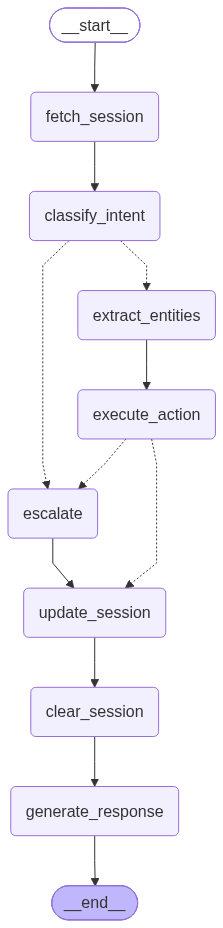

In [12]:
builder = StateGraph(AgentState)

builder.add_node("fetch_session", fetch_session)
builder.add_node("classify_intent", classify_intent)
builder.add_node("extract_entities", extract_entities)
builder.add_node("execute_action", execute_action)
builder.add_node("escalate", escalate)
builder.add_node("update_session", update_session)
builder.add_node("clear_session", clear_session)
builder.add_node("generate_response", generate_response)

builder.set_entry_point("fetch_session")
builder.add_edge("fetch_session", "classify_intent")

builder.add_conditional_edges(
    "classify_intent",
    route_after_classification,
    {"extract_entities": "extract_entities", "escalate": "escalate"},
)

builder.add_edge("extract_entities", "execute_action")

builder.add_conditional_edges(
    "execute_action",
    route_after_action,
    {"update_session": "update_session", "escalate": "escalate"},
)

builder.add_edge("escalate", "update_session")
builder.add_edge("update_session", "clear_session")
builder.add_edge("clear_session", "generate_response")
builder.add_edge("generate_response", END)

graph = builder.compile()
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
result = graph.invoke({
    "session_id": "test-session-1",
    "customer_id": "C1024",
    "customer_message": "I was charged the annual fee twice, please reverse the duplicate charge of 500 rupees, it was 10 days ago.",
    "conversation_memory": {},
    "entities": {},
    "escalate": False,
    "audit_events": [],
})

print(result["response_to_customer"])
print(result["audit_events"])

ConnectTimeout: timed out